# Model fitting 1: Leptonic equilibrim

In [1]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pylab as plt
import jetset
from jetset.test_data_helper import  test_SEDs
from jetset.data_loader import ObsData,Data
from jetset.plot_sedfit import PlotSED
from jetset.test_data_helper import  test_SEDs

In [2]:
print(jetset.__version__)

1.4.0rc0


In [3]:
test_SEDs

['/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_3C345.ecsv',
 '/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk421_EBL_DEABS.ecsv',
 '/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk501_EBL_ABS.ecsv',
 '/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk501_EBL_DEABS.ecsv']

## Loading data



In [4]:
print(test_SEDs[1])
data=Data.from_file(test_SEDs[1])


/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk421_EBL_DEABS.ecsv



***  binning data  ***
---> N bins= 88
---> bin_width= 0.2



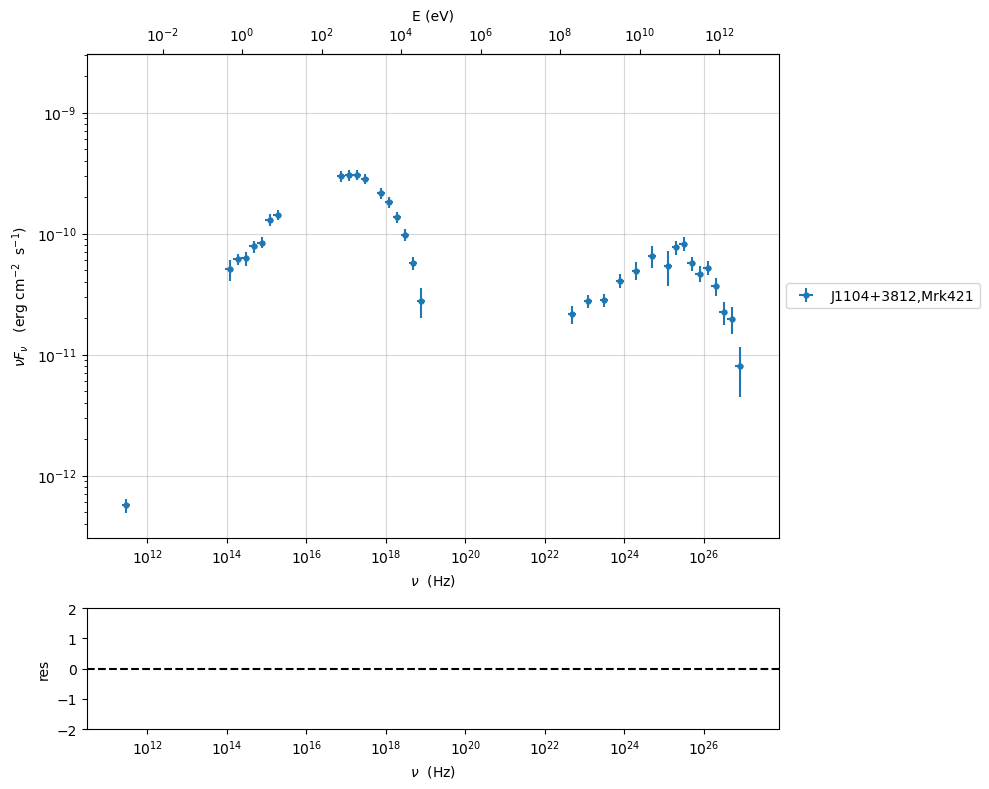

In [5]:
%matplotlib inline
sed_data=ObsData(data_table=data)
sed_data.group_data(bin_width=0.2)

sed_data.add_systematics(0.1,[10.**6,10.**29])
p=sed_data.plot_sed()
#p.setlim(y_min=1E-15,x_min=1E7,x_max=1E29)

In [6]:
sed_data.save('Mrk_401.pkl')

## phenomenological model constraining

### spectral indices


*** evaluating spectral indices for data ***



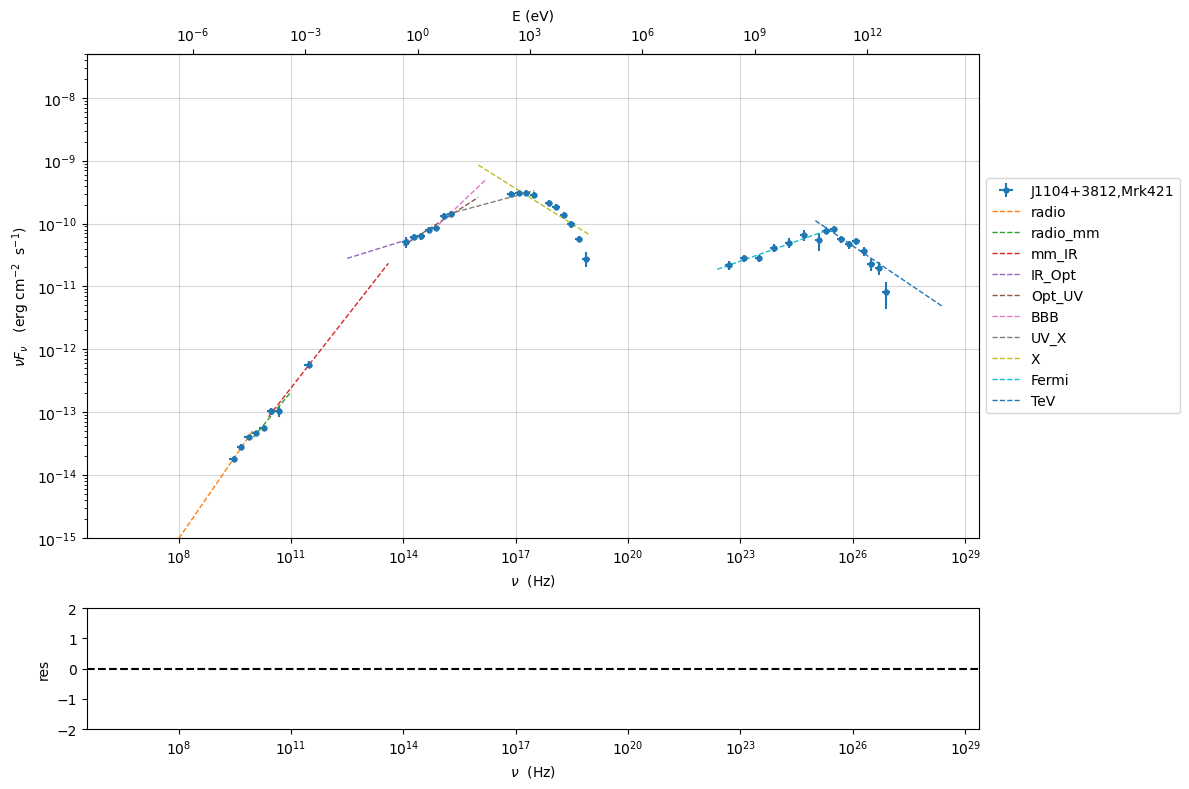

In [7]:
from jetset.sed_shaper import  SEDShape
my_shape=SEDShape(sed_data)
my_shape.eval_indices(minimizer='lsb',silent=True)
p=my_shape.plot_indices()
p.setlim(y_min=1E-15,y_max=5E-8)

### sed shaper

In [8]:
mm,best_fit=my_shape.sync_fit(check_host_gal_template=False,
                  Ep_start=None,
                  minimizer='lsb',
                  silent=True,
                  fit_range=[10.,21.])


*** Log-Polynomial fitting of the synchrotron component ***
---> first blind fit run,  fit range: [10.0, 21.0]
---> class:  HSP





model name,name,val,bestfit val,err +,err -,start val,fit range min,fit range max,frozen
LogCubic,b,-1.563747e-01,-1.563747e-01,5.975434e-03,--,-1.000000e+00,-1.000000e+01,0.000000e+00,False
LogCubic,c,-1.052802e-02,-1.052802e-02,8.781942e-04,--,-1.000000e+00,-1.000000e+01,1.000000e+01,False
LogCubic,Ep,1.675324e+01,1.675324e+01,2.396636e-02,--,1.670206e+01,0.000000e+00,3.000000e+01,False
LogCubic,Sp,-9.494365e+00,-9.494365e+00,1.704982e-02,--,-1.000000e+01,-3.000000e+01,0.000000e+00,False


---> sync       nu_p=+1.675324e+01 (err=+2.396636e-02)  nuFnu_p=-9.494365e+00 (err=+1.704982e-02) curv.=-1.563747e-01 (err=+5.975434e-03)




*** Log-Polynomial fitting of the IC component ***
---> fit range: [23.0, 29.0]
---> LogCubic fit




model name,name,val,bestfit val,err +,err -,start val,fit range min,fit range max,frozen
LogCubic,b,-2.274590e-01,-2.274590e-01,3.262165e-02,--,-1.000000e+00,-1.000000e+01,0.000000e+00,False
LogCubic,c,-6.259967e-02,-6.259967e-02,1.629407e-02,--,-1.000000e+00,-1.000000e+01,1.000000e+01,False
LogCubic,Ep,2.527207e+01,2.527207e+01,8.149544e-02,--,2.528644e+01,0.000000e+00,3.000000e+01,False
LogCubic,Sp,-1.014119e+01,-1.014119e+01,2.734754e-02,--,-1.000000e+01,-3.000000e+01,0.000000e+00,False


---> IC         nu_p=+2.527207e+01 (err=+8.149544e-02)  nuFnu_p=-1.014119e+01 (err=+2.734754e-02) curv.=-2.274590e-01 (err=+3.262165e-02)



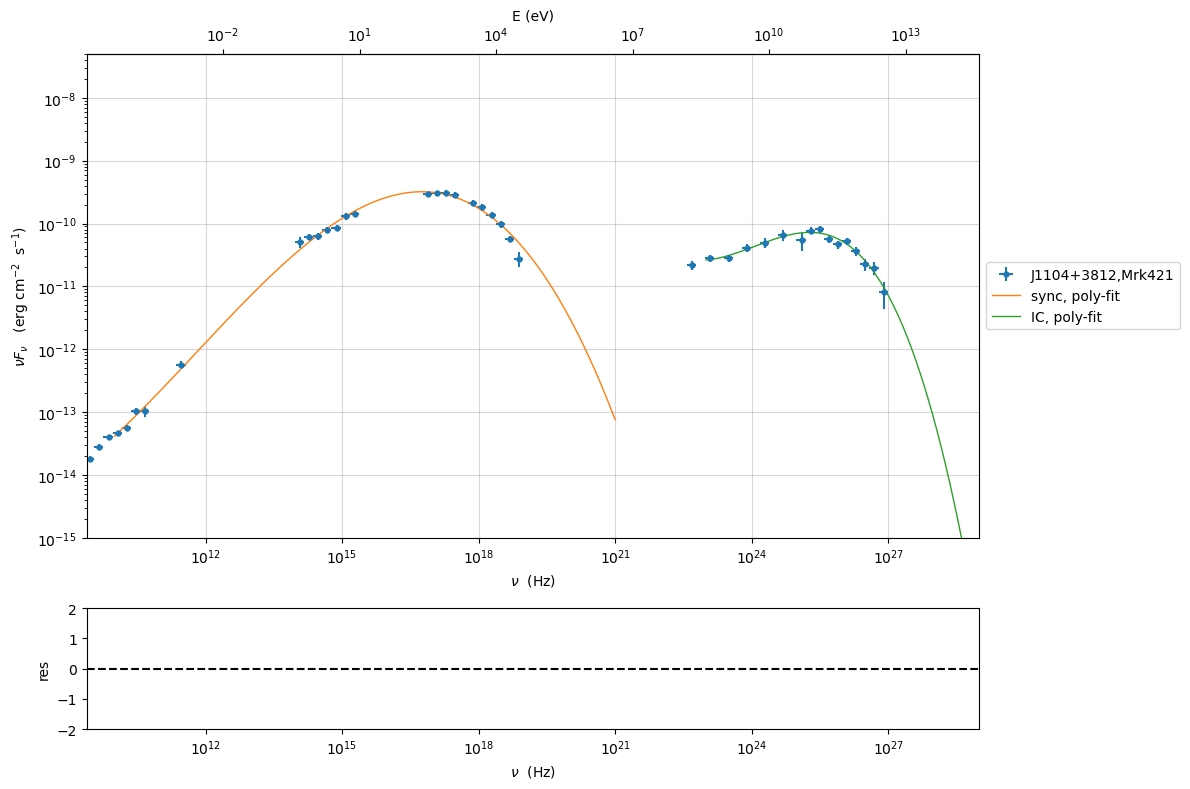

In [9]:
my_shape.IC_fit(fit_range=[23.,29.],minimizer='minuit',silent=True)
p=my_shape.plot_shape_fit()
p.setlim(y_min=1E-15,y_max=5E-8)

### Model constraining

In this step we are not fitting the model, we are just obtaining the phenomenological `pre_fit` model, that will be fitted in using minuit ore least-square bound, as shown below

In [10]:
from jetset.obs_constrain import ObsConstrain


sed_obspar=ObsConstrain(beaming=25,
                        B_range=[0.001,0.1],
                        t_var_sec=3*86400,
                        nu_cut_IR=1E12,
                        distr_e='bkn',
                        SEDShape=my_shape)


prefit_jet=sed_obspar.constrain_SSC_model(electron_distribution_log_values=False,silent=True)
prefit_jet.save_model('prefit_jet.pkl')


***  constrains parameters from observable ***



model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_leptonic,R,region_size,cm,2.219270e+16,1.000000e+03,1.000000e+30,False,False
jet_leptonic,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
jet_leptonic,B,magnetic_field,gauss,6.618390e-02,0.000000e+00,--,False,False
jet_leptonic,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
jet_leptonic,beam_obj,beaming,,2.500000e+01,1.000000e-04,--,False,False
jet_leptonic,z_cosm,redshift,,3.080000e-02,0.000000e+00,--,False,False
jet_leptonic,gmin,low-energy-cut-off,lorentz-factor*,4.103365e+02,1.000000e+00,1.000000e+09,False,False
jet_leptonic,gmax,high-energy-cut-off,lorentz-factor*,1.136207e+06,1.000000e+00,1.000000e+15,False,False
jet_leptonic,N,emitters_density,1 / cm3,1.238758e+00,0.000000e+00,--,False,False
jet_leptonic,gamma_break,turn-over-energy,lorentz-factor*,9.766963e+04,1.000000e+00,1.000000e+09,False,False


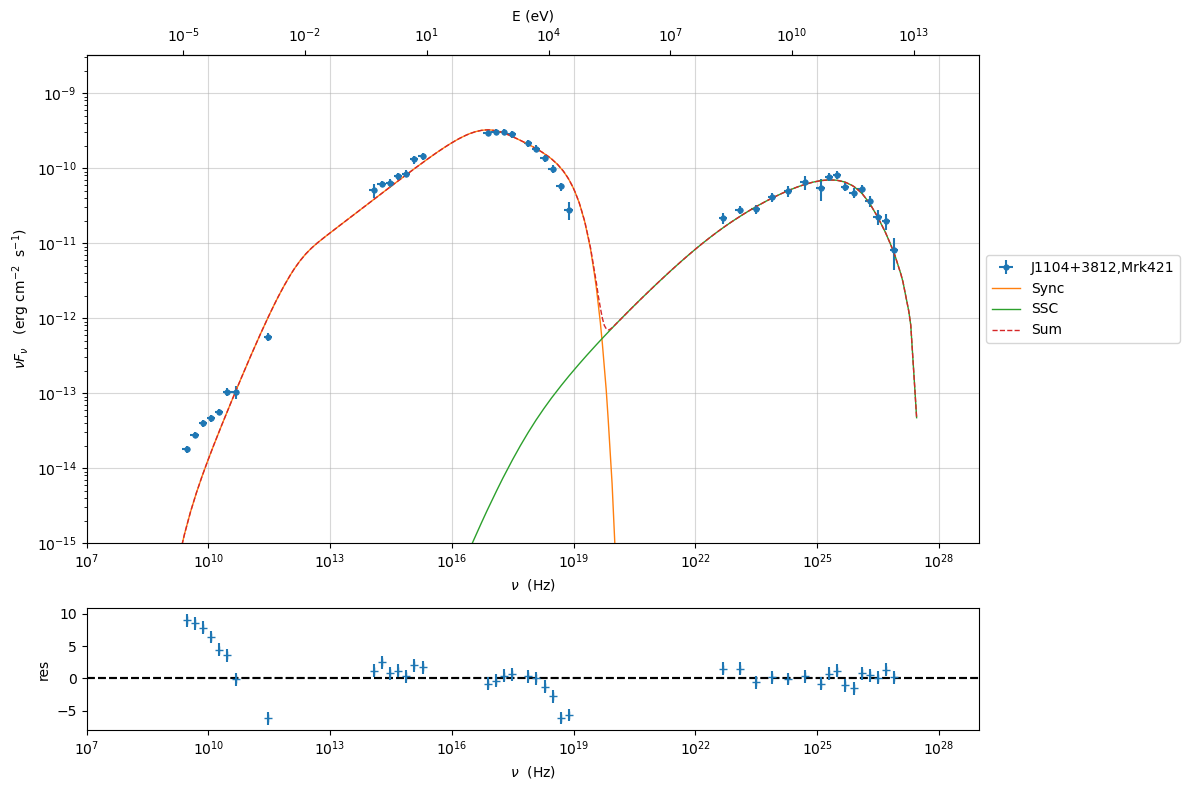

In [11]:
prefit_jet.eval()
pl=prefit_jet.plot_model(sed_data=sed_data)
pl.add_residual_plot(prefit_jet,sed_data)
pl.setlim(y_min=1E-15,x_min=1E7,x_max=1E29)

## Enabling the leptonic equilibrium

We build a jet with the leptonic equilibrium, and we copy the relevant parameters from the `prefit_jet` model

In [12]:
from jetset.jet_emitters_factory import InjEmittersFactory
from jetset.jet_model import Jet

q_inj = InjEmittersFactory().create_inj_emitters('pl')

lept_eq_jet=Jet(emitters_distribution=q_inj,name='leptonic_eq')
lept_eq_jet.parameters.p.val=prefit_jet.parameters.p.val
lept_eq_jet.parameters.z_cosm.val=prefit_jet.parameters.z_cosm.val
lept_eq_jet.parameters.R.val=prefit_jet.parameters.R.val
lept_eq_jet.parameters.B.val=prefit_jet.parameters.B.val
lept_eq_jet.parameters.gmin.val=prefit_jet.parameters.gmin.val
lept_eq_jet.parameters.gmax.val=prefit_jet.parameters.gmax.val

lept_eq_jet.parameters.beam_obj.val=prefit_jet.parameters.beam_obj.val


for the emitters density we use the standard tool

In [13]:
lept_eq_jet.set_N_from_nuFnu(nu_obs=1E15,nuFnu_obs=1E-10)

L_out 1.6340495211662187e+43 2.3263510983670636e+44
L_out 1.4236723356503605e+41


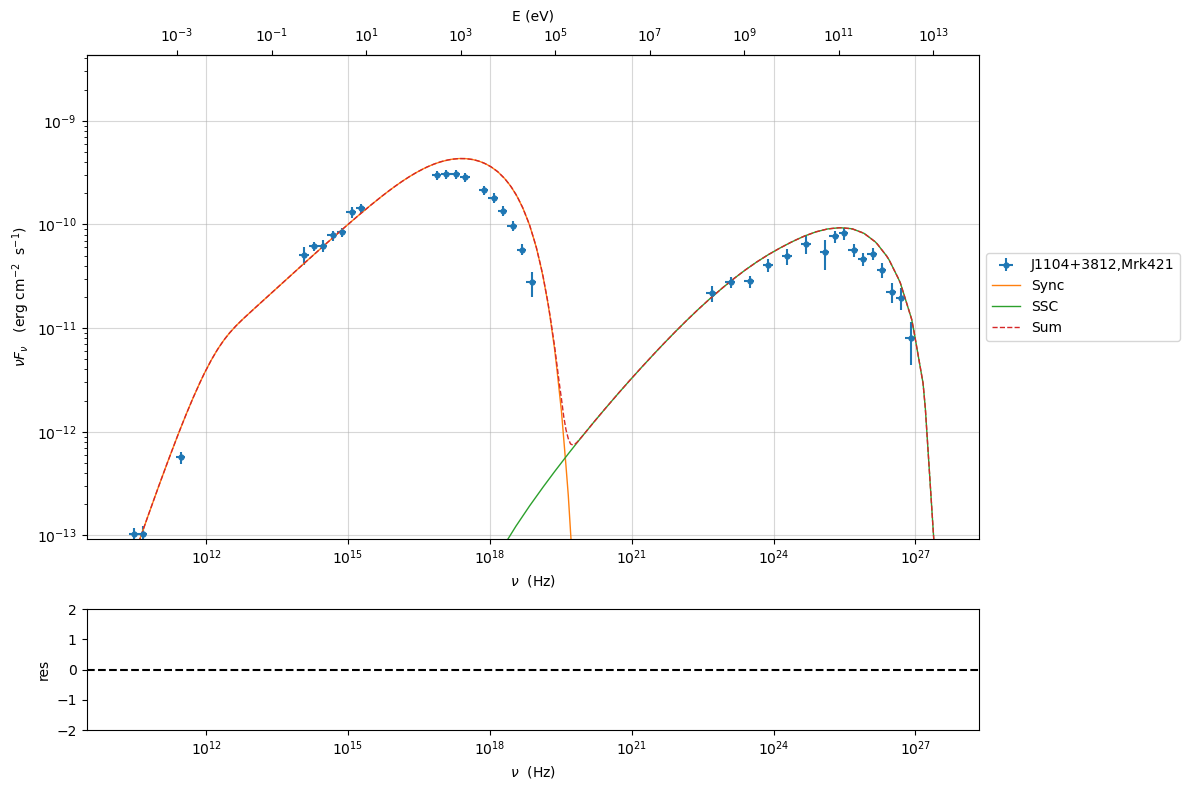

In [14]:
lept_eq_jet.eval()
lept_eq_jet.plot_model(sed_data=sed_data)

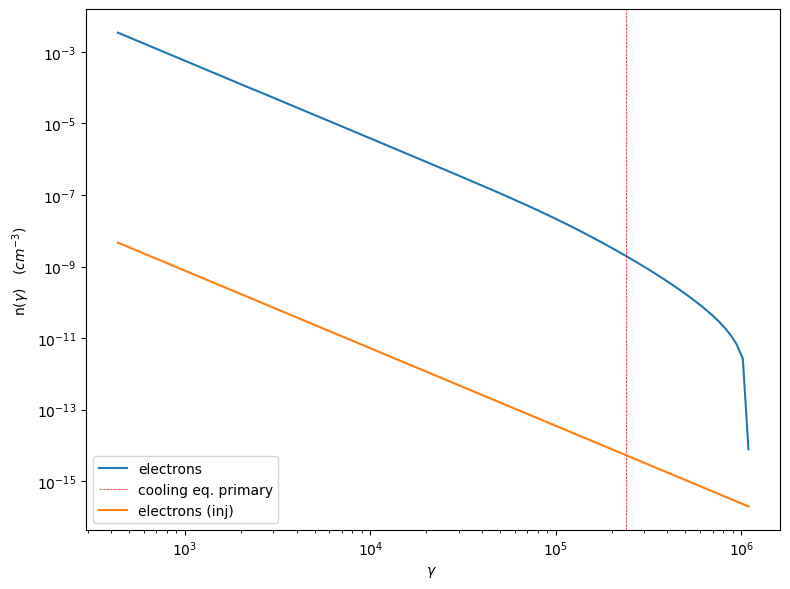

In [15]:
lept_eq_jet.emitters_distribution.plot()

In [16]:
lept_eq_jet.parameters

model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
leptonic_eq,R,region_size,cm,2.219270e+16,1.000000e+03,1.000000e+30,False,False
leptonic_eq,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
leptonic_eq,B,magnetic_field,gauss,6.618390e-02,0.000000e+00,--,False,False
leptonic_eq,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
leptonic_eq,beam_obj,beaming,,2.500000e+01,1.000000e-04,--,False,False
leptonic_eq,z_cosm,redshift,,3.080000e-02,0.000000e+00,--,False,False
leptonic_eq,gmin,low-energy-cut-off,lorentz-factor*,4.103365e+02,1.000000e+00,1.000000e+09,False,False
leptonic_eq,gmax,high-energy-cut-off,lorentz-factor*,1.136207e+06,1.000000e+00,1.000000e+15,False,False
leptonic_eq,p,LE_spectral_slope,,2.169388e+00,-1.000000e+01,1.000000e+01,False,False
leptonic_eq,T_esc_e_primaries,escape_time,R / c,1.000000e+00,1.000000e+00,--,False,False


None

## Model fitting procedure

### Model fitting with LSB

In [17]:
from jetset.minimizer import ModelMinimizer

from jetset.model_manager import  FitModel


We use the `lept_eq_jet` model to build the `FitModel`

In [18]:
fit_model=FitModel( jet=lept_eq_jet, name='SSC-best-fit',template=None) 

In [19]:
fit_model.show_model_components()


--------------------------------------------------------------------------------
Composite model description
--------------------------------------------------------------------------------
name: SSC-best-fit  
type: composite_model  
components models:
 -model name: leptonic_eq model type: jet

--------------------------------------------------------------------------------


There is only one component, whit name `leptonic_eq`, that refers to the `lept_eq_jet` model component

We now set the gamma grid size to 200, ad we set `composite_expr`, anyhow, since we have only one component this step could be skipped

In [20]:
fit_model.leptonic_eq.set_gamma_grid_size(200)
fit_model.composite_expr='leptonic_eq'

#### Freezeing parameters and setting fit_range intervals

In [21]:

fit_model.freeze('leptonic_eq','z_cosm')
fit_model.freeze('leptonic_eq','R_H')
fit_model.freeze('leptonic_eq','T_esc_e_primaries')

fit_model.leptonic_eq.parameters.R.fit_range=[10**15.5,10**17.5]
fit_model.leptonic_eq.parameters.beam_obj.fit_range=[5., 50.]
fit_model.leptonic_eq.parameters.gmax.fit_range=[1E5, 5E6]
fit_model.leptonic_eq.parameters.gmin.fit_range=[10, 1000]
fit_model.leptonic_eq.parameters.T_esc_e_primaries.val=1
fit_model.leptonic_eq.parameters.L_inj.fit_range=[1E38, 1E43]



In [22]:
fit_model.parameters

model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
leptonic_eq,R,region_size,cm,2.219270e+16,1.000000e+03,1.000000e+30,False,False
leptonic_eq,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
leptonic_eq,B,magnetic_field,gauss,6.618390e-02,0.000000e+00,--,False,False
leptonic_eq,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
leptonic_eq,beam_obj,beaming,,2.500000e+01,1.000000e-04,--,False,False
leptonic_eq,z_cosm,redshift,,3.080000e-02,0.000000e+00,--,False,True
leptonic_eq,gmin,low-energy-cut-off,lorentz-factor*,4.103365e+02,1.000000e+00,1.000000e+09,False,False
leptonic_eq,gmax,high-energy-cut-off,lorentz-factor*,1.136207e+06,1.000000e+00,1.000000e+15,False,False
leptonic_eq,p,LE_spectral_slope,,2.169388e+00,-1.000000e+01,1.000000e+01,False,False
leptonic_eq,T_esc_e_primaries,escape_time,R / c,1.000000e+00,1.000000e+00,--,False,True


None

#### Building the ModelMinimizer object

In [23]:
model_minimizer_minuit=ModelMinimizer('minuit')
best_fit_minuit=model_minimizer_minuit.fit(fit_model,
                                           sed_data,
                                           1E11,
                                           1E29,
                                           fitname='SSC-best-fit-minuit',
                                           max_ev=10000,
                                           repeat=1)

filtering data in fit range = [1.000000e+11,1.000000e+29]
data length 34

*** start fit process ***
----- 


0it [00:00, ?it/s]

- best chisq=4.88440e+01

-------------------------------------------------------------------------
Fit report

Model: SSC-best-fit-minuit


model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
leptonic_eq,R,region_size,cm,2.915423e+16,1.000000e+03,1.000000e+30,False,False
leptonic_eq,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
leptonic_eq,B,magnetic_field,gauss,9.177237e-02,0.000000e+00,--,False,False
leptonic_eq,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
leptonic_eq,beam_obj,beaming,,1.774807e+01,1.000000e-04,--,False,False
leptonic_eq,z_cosm,redshift,,3.080000e-02,0.000000e+00,--,False,True
leptonic_eq,gmin,low-energy-cut-off,lorentz-factor*,4.288467e+02,1.000000e+00,1.000000e+09,False,False
leptonic_eq,gmax,high-energy-cut-off,lorentz-factor*,9.276581e+05,1.000000e+00,1.000000e+15,False,False
leptonic_eq,p,LE_spectral_slope,,2.048689e+00,-1.000000e+01,1.000000e+01,False,False
leptonic_eq,T_esc_e_primaries,escape_time,R / c,1.000000e+00,1.000000e+00,--,False,True



converged=True
calls=2679
mesg=


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 48.84                      │             Nfcn = 2679              │
│ EDM = 10.7 (Goal: 0.0002)        │           time = 23.8 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   ABOVE EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │     Covariance FORCED pos. def.      │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ par_0 │ 29.154e15 │ 0.010e15  │            │            │3.16228e+15│3.16228e+17│       │
│ 1 │ par_1 │  0.0918   │  0.0031   │            │            │    0    │         │       │
│ 2 │ par_2 │   17.7    │    0.4    │            │            │    5    │   50    │       │
│ 3 │ par_3 │  428.847  │   0.005   │            │            │   10    │  1000   │       │
│ 4 │ par_4 │  0.93e6   │  0.16e6   │            │            │ 100000  │  5e+06  │       │
│ 5 │ par_5 │   2.05    │   0.07    │            │            │   -10   │   10    │       │
│ 6 │ par_6 │ 0.218e42  │ 0.014e42  │            │            │  1e+38  │  1e+43  │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘

dof=27
chisq=48.844023, chisq/red=1.809038 null hypothesis sig=0.006170

best fit pars


model name,name,val,bestfit val,err +,err -,start val,fit range min,fit range max,frozen
leptonic_eq,R,2.915423e+16,2.915423e+16,1.051357e+13,--,2.219270e+16,3.162278e+15,3.162278e+17,False
leptonic_eq,R_H,1.000000e+17,--,--,--,1.000000e+17,0.000000e+00,--,True
leptonic_eq,B,9.177237e-02,9.177237e-02,3.093967e-03,--,6.618390e-02,0.000000e+00,--,False
leptonic_eq,NH_cold_to_rel_e,1.000000e+00,--,--,--,1.000000e+00,0.000000e+00,--,True
leptonic_eq,beam_obj,1.774807e+01,1.774807e+01,3.756669e-01,--,2.500000e+01,5.000000e+00,5.000000e+01,False
leptonic_eq,z_cosm,3.080000e-02,--,--,--,3.080000e-02,0.000000e+00,--,True
leptonic_eq,gmin,4.288467e+02,4.288467e+02,4.726429e-03,--,4.103365e+02,1.000000e+01,1.000000e+03,False
leptonic_eq,gmax,9.276581e+05,9.276581e+05,1.598030e+05,--,1.136207e+06,1.000000e+05,5.000000e+06,False
leptonic_eq,p,2.048689e+00,2.048689e+00,6.774985e-02,--,2.169388e+00,-1.000000e+01,1.000000e+01,False
leptonic_eq,T_esc_e_primaries,1.000000e+00,--,--,--,1.000000e+00,1.000000e+00,--,True


-------------------------------------------------------------------------




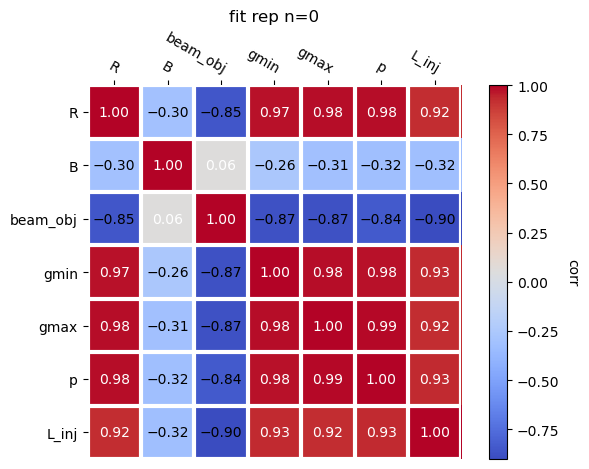

In [24]:
p=model_minimizer_minuit.plot_corr_matrix()

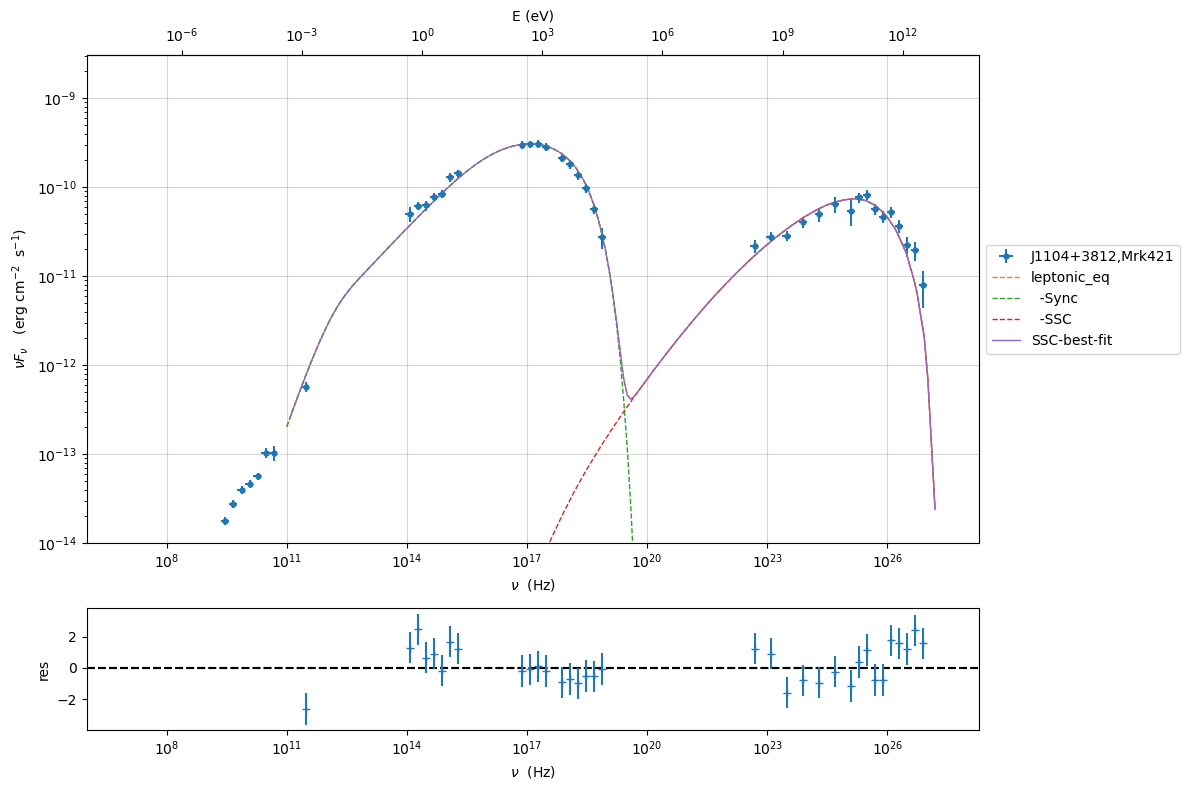

In [25]:
%matplotlib inline
fit_model.eval()
p2=fit_model.plot_model(sed_data=sed_data)
p2.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

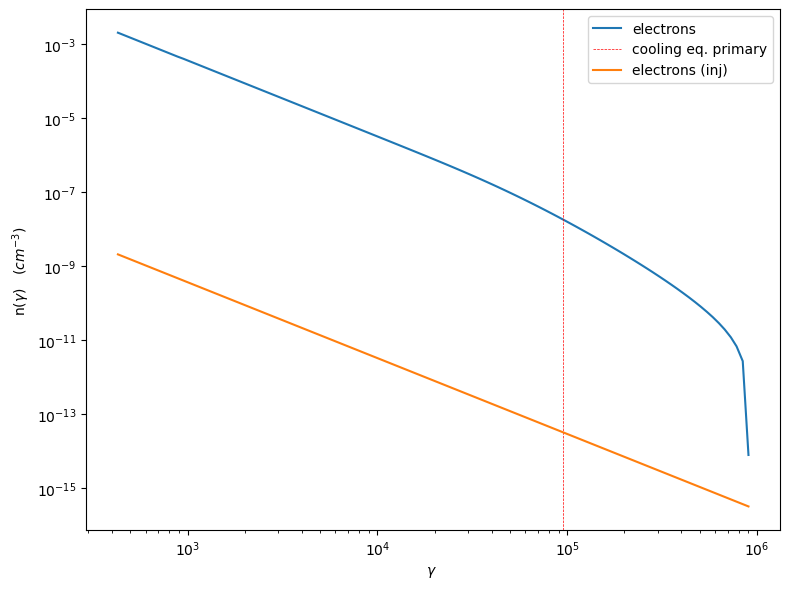

In [26]:
fit_model.leptonic_eq.emitters_distribution.plot()


#### saving fit model, model minimizer

In [27]:
best_fit_minuit.save_report('SSC-best-fit-minuit.pkl')
model_minimizer_minuit.save_model('model_minimizer_minuit.pkl')
fit_model.save_model('fit_model_minuit.pkl')

## MCMC sampling

### creating and setting the sampler

In [28]:
from jetset.mcmc import McmcSampler
from jetset.minimizer import ModelMinimizer


In [29]:
model_minimizer_minuit = ModelMinimizer.load_model('model_minimizer_minuit.pkl')

mcmc=McmcSampler(model_minimizer_minuit)


In [30]:
labels=['L_inj','B','beam_obj','R','p']
model_name='leptonic_eq'
use_labels_dict={model_name:labels}

mcmc.set_labels(use_labels_dict=use_labels_dict)

In [31]:
mcmc.set_bounds(bound=5.0,bound_rel=True)


par: L_inj  best fit value:  2.181277321031021e+41  mcmc bounds: [1e+38, np.float64(1.3087663926186125e+42)]
par: B  best fit value:  0.09177236691672452  mcmc bounds: [0, np.float64(0.5506342015003471)]
par: beam_obj  best fit value:  17.748068059424398  mcmc bounds: [5.0, 50.0]
par: R  best fit value:  2.9154231588805704e+16  mcmc bounds: [3162277660168379.5, np.float64(1.749253895328342e+17)]
par: p  best fit value:  2.0486894279548906  mcmc bounds: [np.float64(-8.194757711819562), 10]


In [32]:


#NOTE: preserve_fit_range=True preserves the model fit range for each parameter used in the MCMC
mcmc.set_bounds(bound=5.0,bound_rel=True,preserve_fit_range=True)

par: L_inj  best fit value:  2.181277321031021e+41  mcmc bounds: [1e+38, np.float64(1.3087663926186125e+42)]
par: B  best fit value:  0.09177236691672452  mcmc bounds: [0, np.float64(0.5506342015003471)]
par: beam_obj  best fit value:  17.748068059424398  mcmc bounds: [5.0, 50.0]
par: R  best fit value:  2.9154231588805704e+16  mcmc bounds: [3162277660168379.5, np.float64(1.749253895328342e+17)]
par: p  best fit value:  2.0486894279548906  mcmc bounds: [np.float64(-8.194757711819562), 10]


In [33]:
mcmc.run_sampler(nwalkers=20, burnin=50,steps=500,progress='notebook')

mcmc run starting



  0%|          | 0/500 [00:00<?, ?it/s]

mcmc run done, with 1 threads took 127.93 seconds
----------------------------
MCMC best fit solution
L_inj: 2.5379973193493358e+41
B: 0.09518968755529787
beam_obj: 16.33028232860727
R: 3.3257247384800336e+16
p: 1.9944227595464585
----------------------------


Showing the MCMC parameters. Now MCMC bestfit values are updated to the best-fit MCMC solution


In [34]:
mcmc.par_table

idx,model name,name,current val,mcmc best fit val,quantile 0.16,quantile 0.50,quantile 0.84,val min,val max,mcmc bound min,mcmc bound max,units,plot label
int64,str11,str8,float64,float64,float64,float64,float64,float64,object,float64,float64,str7,str8
0,leptonic_eq,L_inj,2.5379973193493358e+41,2.5379973193493358e+41,2.1867930884430712e+41,2.491540763766256e+41,2.8282280337576004e+41,0.0,None,1e+38,1.3087663926186125e+42,erg / s,L_inj
1,leptonic_eq,B,0.09518968755529787,0.09518968755529787,0.08720791804708543,0.0938643557812696,0.09980040681544372,0.0,None,0.0,0.5506342015003471,gauss,B
2,leptonic_eq,beam_obj,16.33028232860727,16.33028232860727,15.542674793711477,16.551971318448267,17.641402456575815,0.0001,None,5.0,50.0,,beam_obj
3,leptonic_eq,R,3.3257247384800336e+16,3.3257247384800336e+16,2.8985855002658204e+16,3.2668460989701056e+16,3.737521481393122e+16,1000.0,1e+30,3162277660168379.5,1.749253895328342e+17,cm,R
4,leptonic_eq,p,1.9944227595464585,1.9944227595464585,1.9605747375242233,2.0048053234657277,2.04560514893497,-10.0,10,-8.194757711819562,10.0,,p


### plotting the posterior corner plot

To have a better rendering on the scatter plot, we redefine the plot labels

In [35]:
mcmc.set_plot_label('L_inj',r'$L_{inj}$')
mcmc.set_plot_label('B',r'$B$')
mcmc.set_plot_label('beam_obj',r'$\delta$')
mcmc.set_plot_label('p',r'$p$')


the code below lets you tuning the output

1) mpl.rcParams['figure.dpi'] if you increase it you get a better definition
2) title_fmt=".2E" this is the format for python, 2 significant digits, scientific notation
3) title_kwargs=dict(fontsize=12) you can change the fontsize

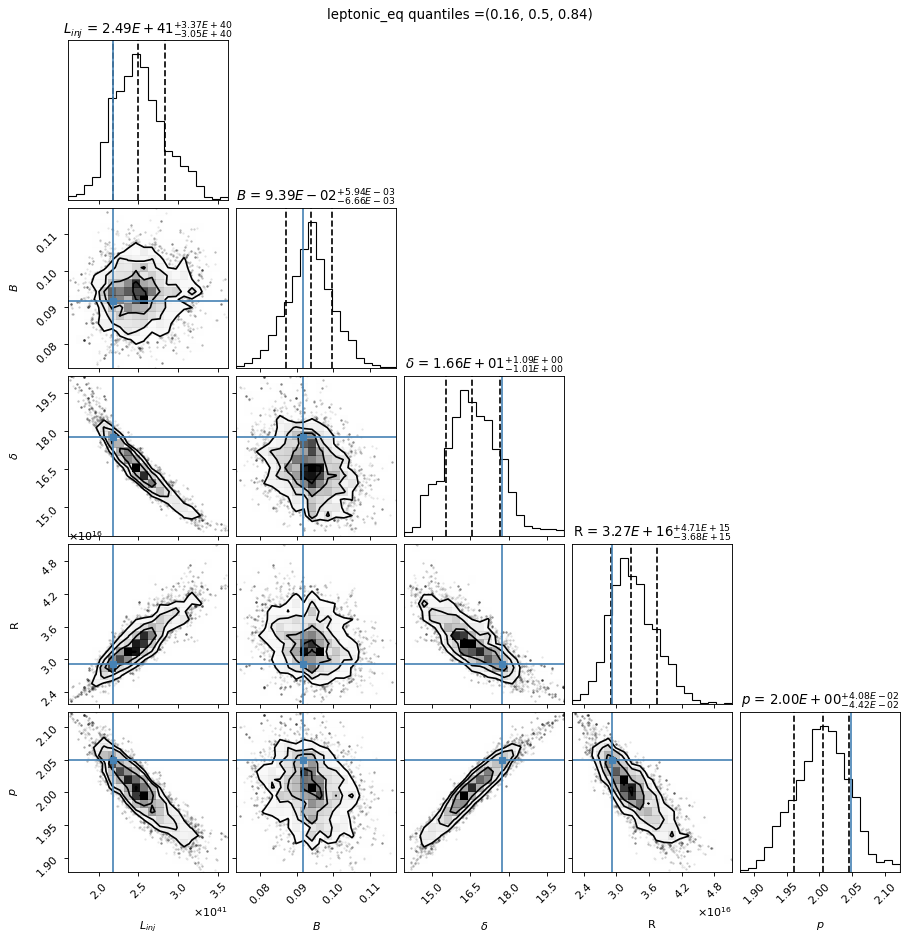

In [36]:
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 80
f=mcmc.corner_plot(quantiles=(0.16, 0.5, 0.84),title_kwargs=dict(fontsize=12),title_fmt=".2E",use_math_text=True)


In [37]:
print(mcmc.acceptance_fraction)

0.5191000000000001


### plotting the model

To plot the sampled model range against the input best-fit model

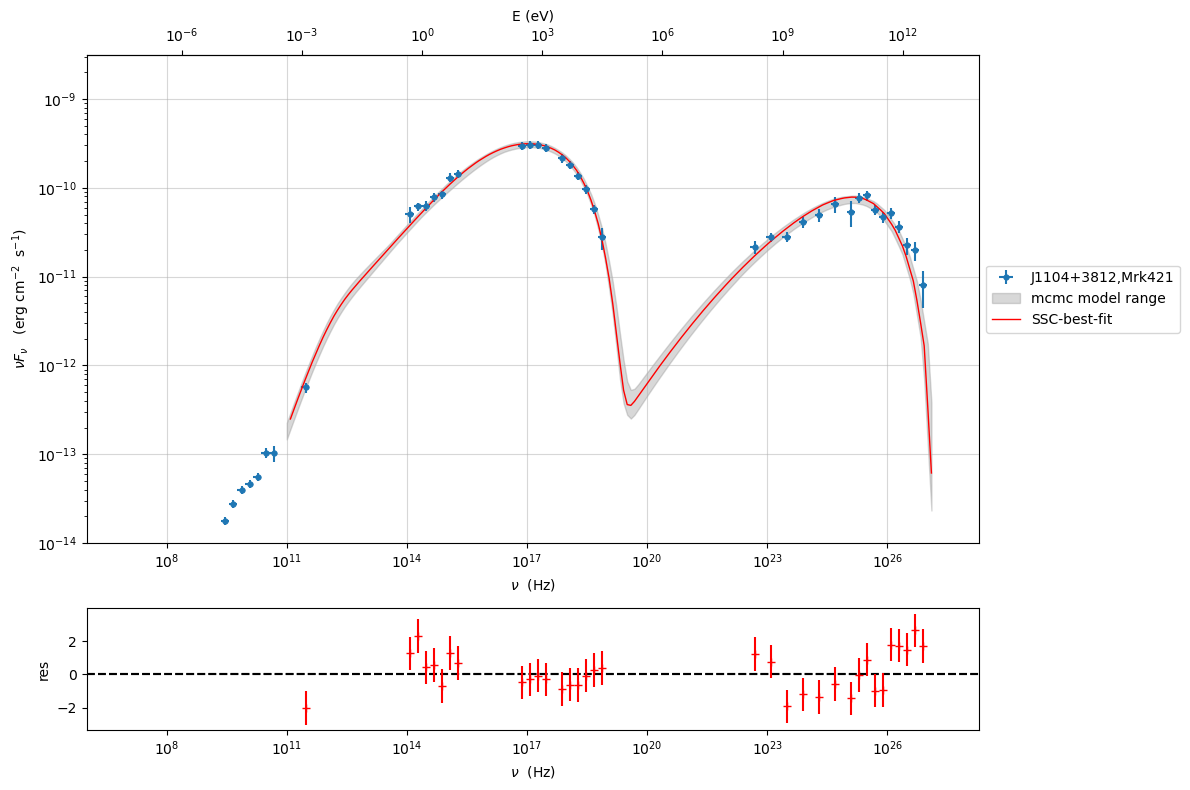

In [38]:
mpl.rcParams['figure.dpi'] = 80
p=mcmc.plot_model(sed_data=sed_data,fit_range=[1E11,1E29],size=100)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

To plot the sampled model range,providing quantiles, against the input best-fit model, providing quantiles

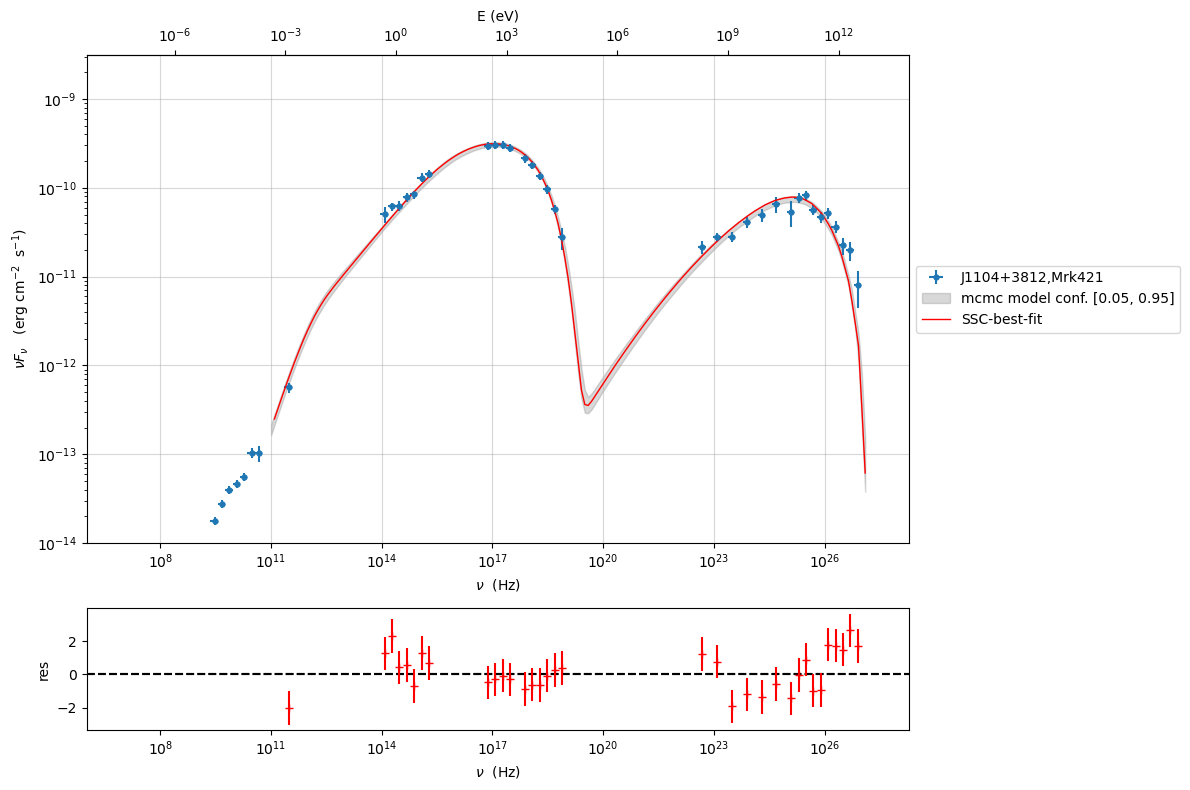

In [39]:
mpl.rcParams['figure.dpi'] = 80
p=mcmc.plot_model(sed_data=sed_data,fit_range=[1E11, 2E29],size=100,quantiles=[0.05,0.95])
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

To plot the sampled model range,providing quantiles, against the mcmc model at 0.5 quantile (``plot_mcmc_best_fit_model==True`` provides the 0.5 quantile sampled model)

----------------------------
MCMC best fit solution
L_inj: 2.5379973193493358e+41
B: 0.09518968755529787
beam_obj: 16.33028232860727
R: 3.3257247384800336e+16
p: 1.9944227595464585
----------------------------


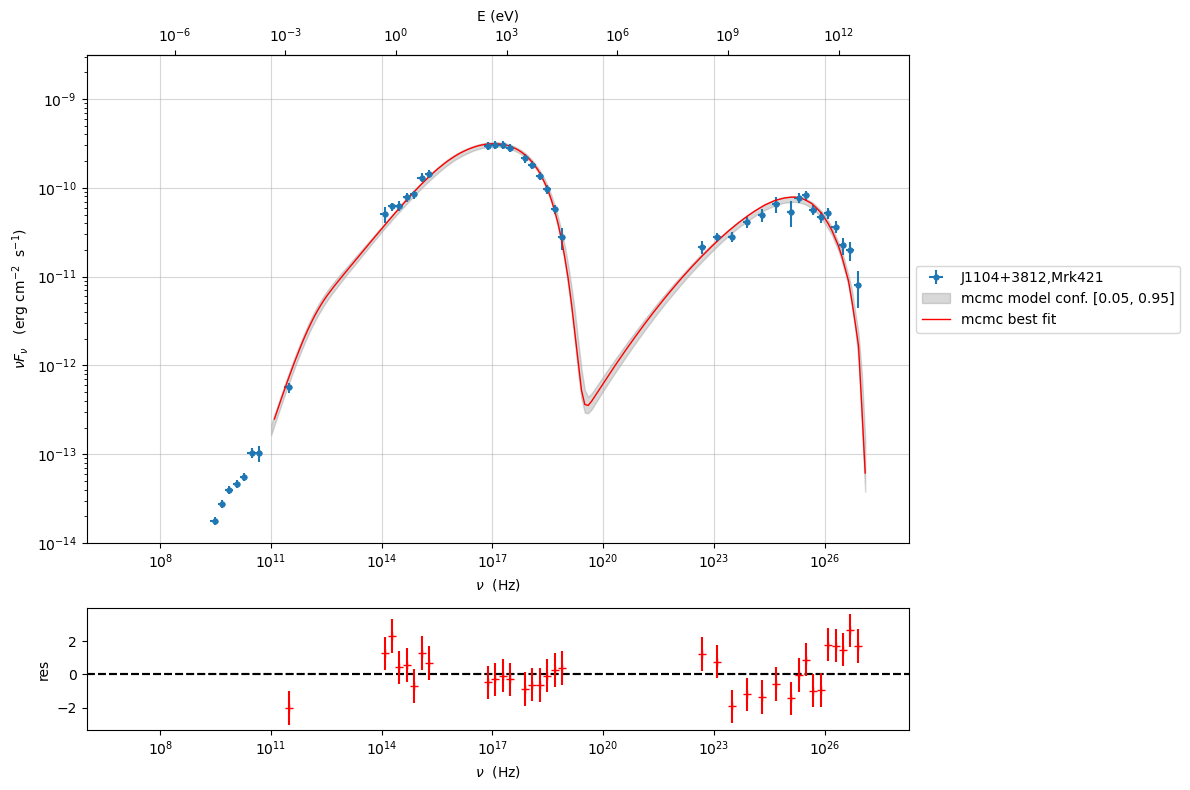

In [40]:
mpl.rcParams['figure.dpi'] = 100
p=mcmc.plot_model(sed_data=sed_data,fit_range=[1E11, 1E29],size=100,quantiles=[0.05,0.95], plot_mcmc_best_fit_model=True)

p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

### plotting chains and individual posteriors

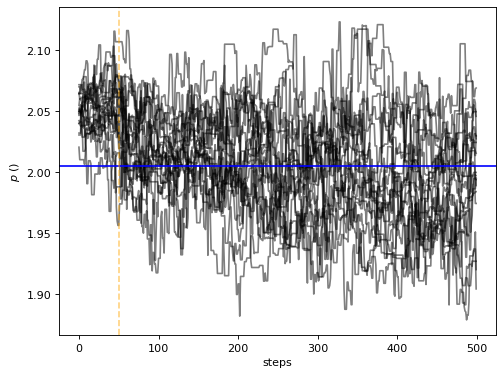

In [41]:
mpl.rcParams['figure.dpi'] = 80
f=mcmc.plot_chain(par_name='p',log_plot=False)
plt.tight_layout()

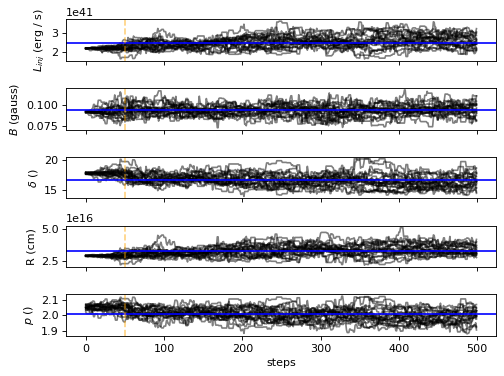

In [42]:
mpl.rcParams['figure.dpi'] = 80
f=mcmc.plot_chain(log_plot=False)
plt.tight_layout()

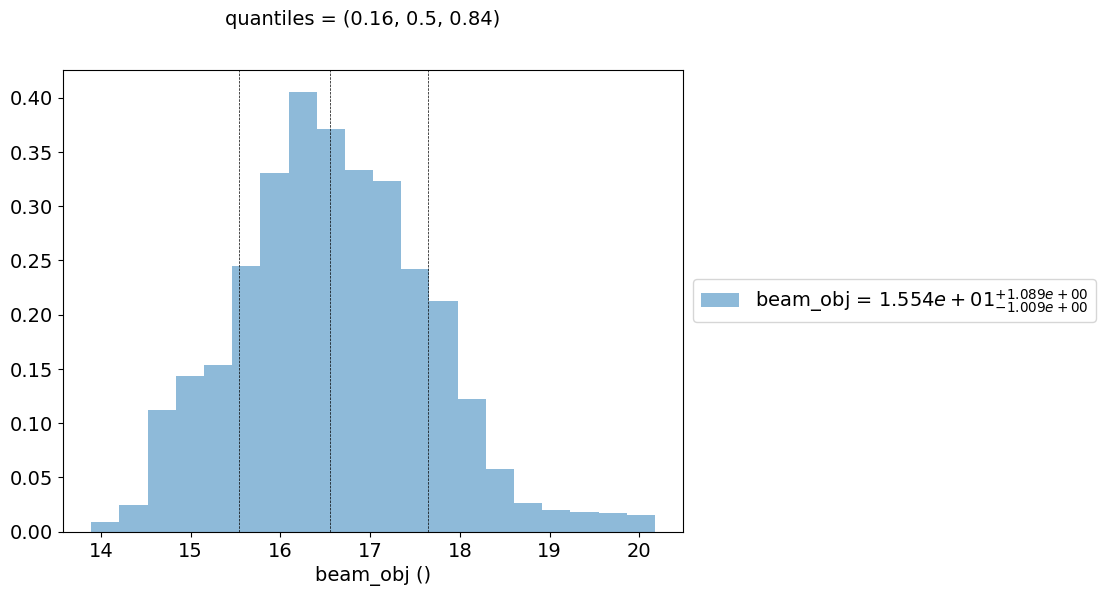

In [43]:

f=mcmc.plot_par('beam_obj',figsize=(8,6))
mpl.rcParams['figure.dpi'] = 80

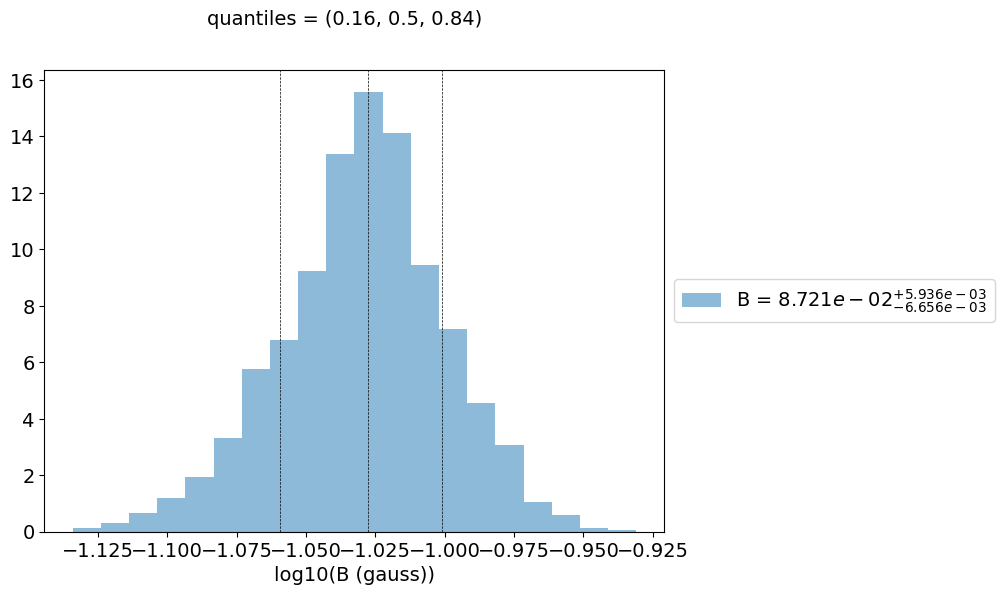

In [44]:
mpl.rcParams['figure.dpi'] = 80
f=mcmc.plot_par('B',log_plot=True,figsize=(8,6))

## Save and reuse MCMC

In [45]:
mcmc.save('mcmc_sampler.pkl')

In [46]:
from jetset.mcmc import McmcSampler
from jetset.data_loader import ObsData
from jetset.plot_sedfit import PlotSED
from jetset.test_data_helper import  test_SEDs

sed_data=ObsData.load('Mrk_401.pkl')
ms=McmcSampler.load('mcmc_sampler.pkl')

import matplotlib as mpl


In [47]:
ms.model.name

'SSC-best-fit'

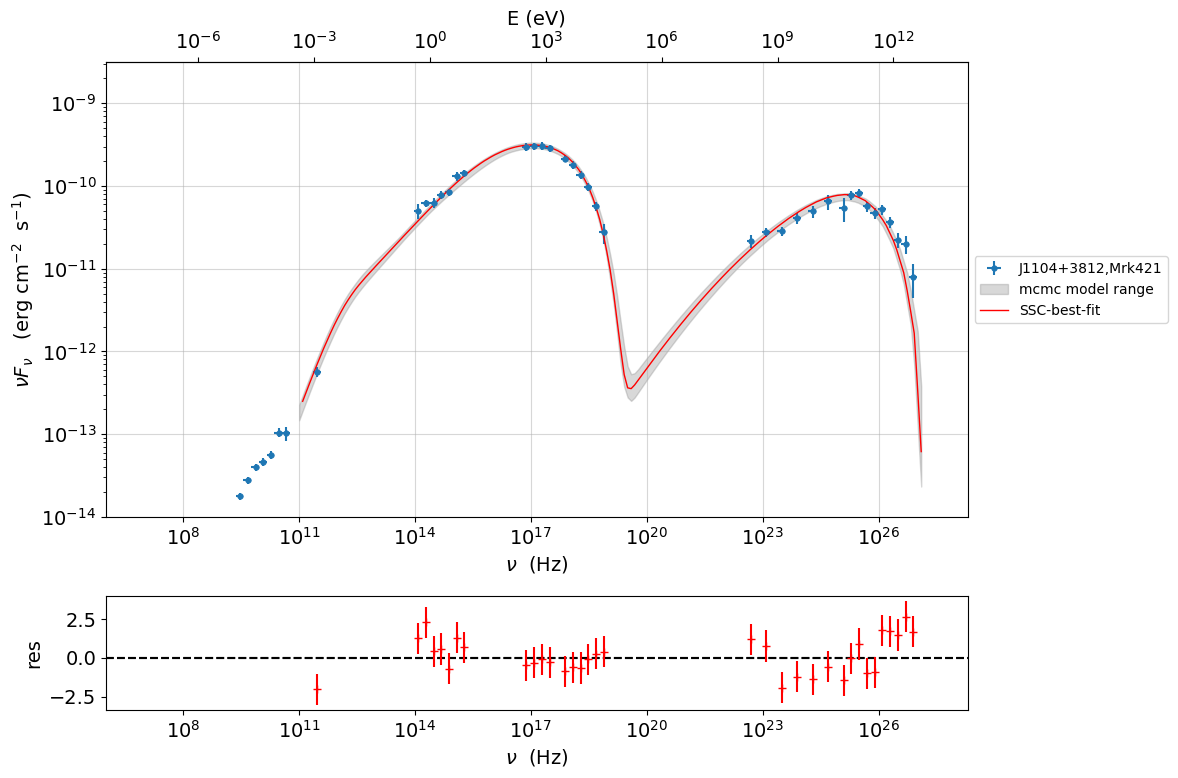

In [48]:
mpl.rcParams['figure.dpi'] = 80
p=ms.plot_model(sed_data=sed_data,fit_range=[1E11, 1E29],size=100)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

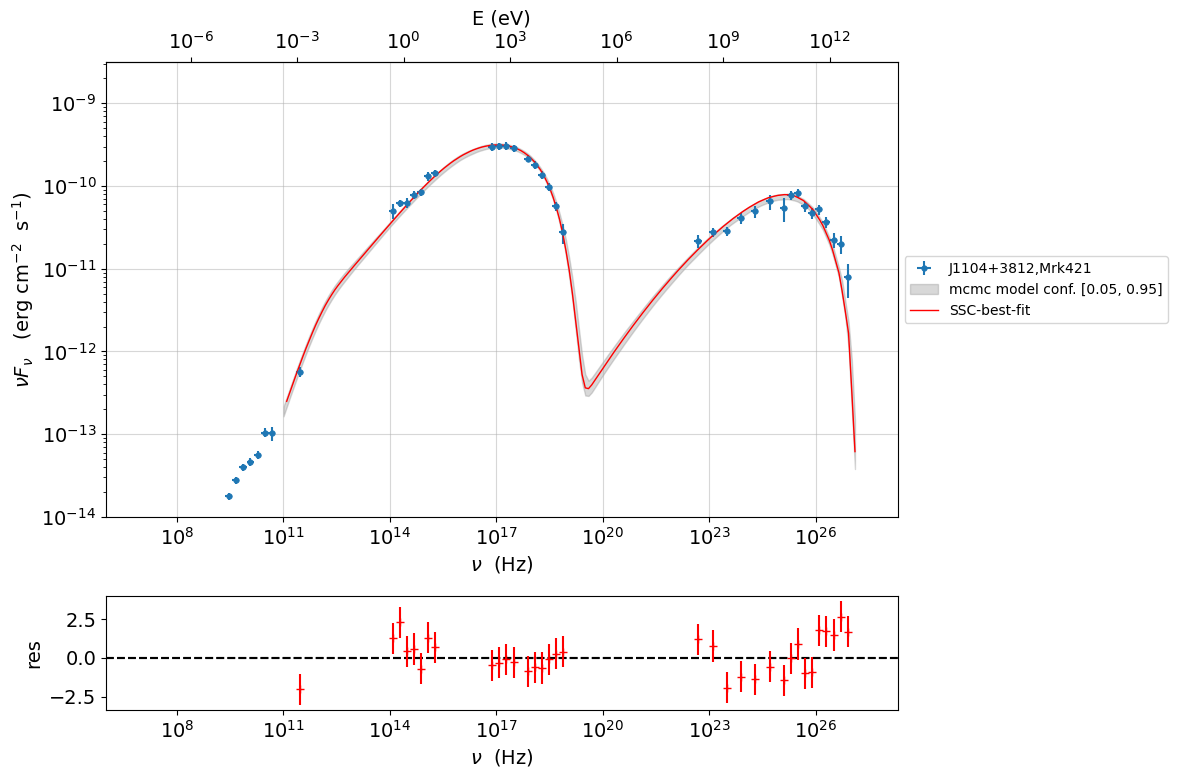

In [49]:
mpl.rcParams['figure.dpi'] = 80
p=ms.plot_model(sed_data=sed_data,fit_range=[1E11, 1E29],size=100,quantiles=[0.05,0.95])

p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

----------------------------
MCMC best fit solution
L_inj: 2.5379973193493358e+41
B: 0.09518968755529787
beam_obj: 16.33028232860727
R: 3.3257247384800336e+16
p: 1.9944227595464585
----------------------------


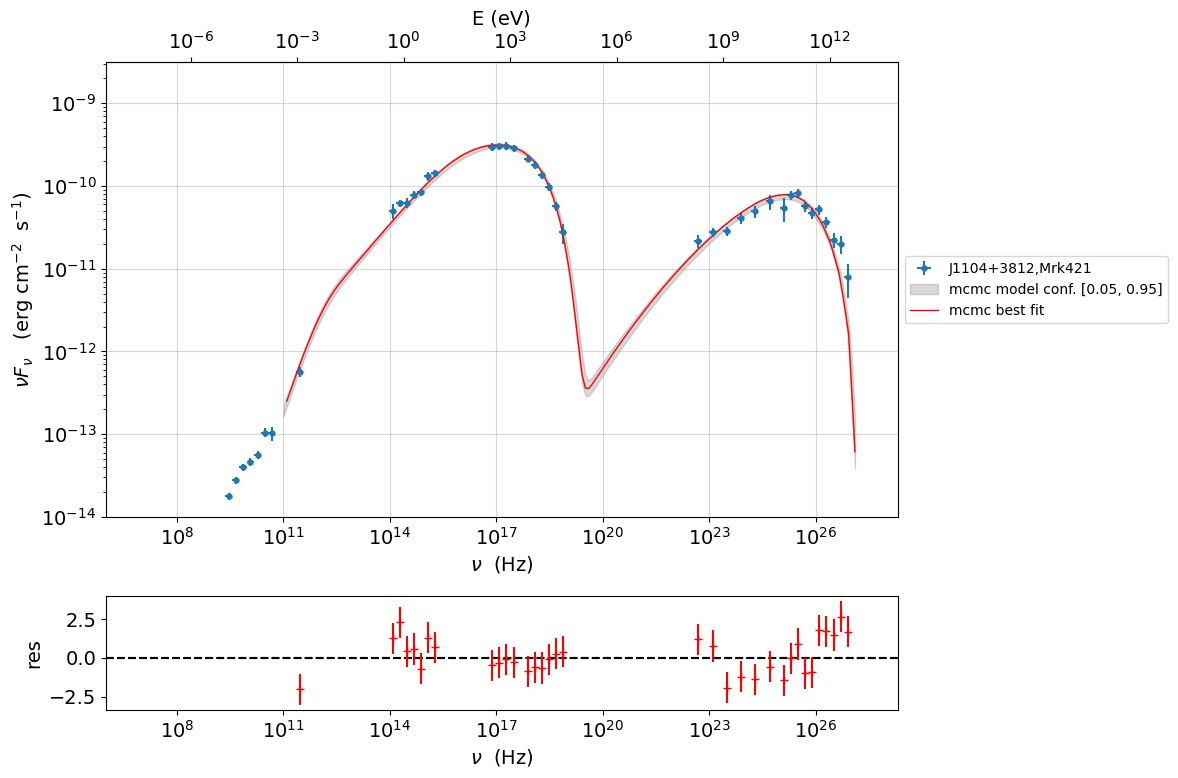

In [50]:
mpl.rcParams['figure.dpi'] = 80
p=ms.plot_model(sed_data=sed_data,fit_range=[1E11, 1E29],size=100,quantiles=[0.05,0.95],plot_mcmc_best_fit_model=True)

p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

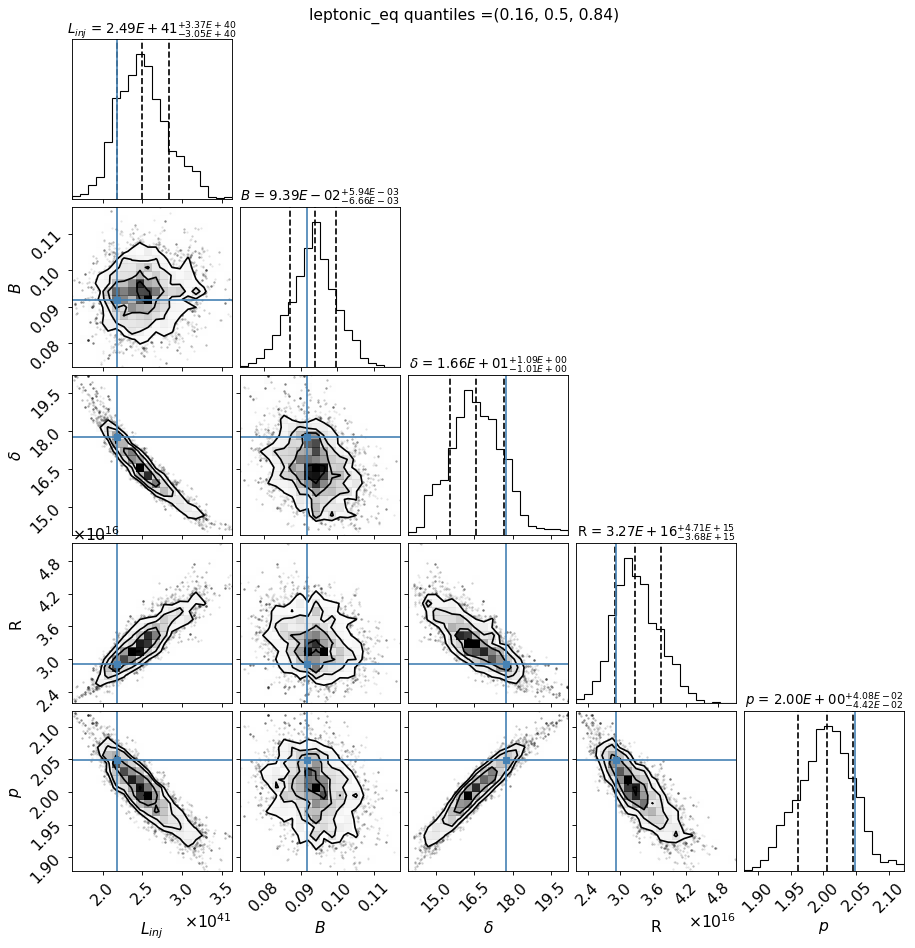

In [51]:
mpl.rcParams['figure.dpi'] = 80
f=ms.corner_plot(quantiles=(0.16, 0.5, 0.84),title_kwargs=dict(fontsize=12),title_fmt=".2E",use_math_text=True)

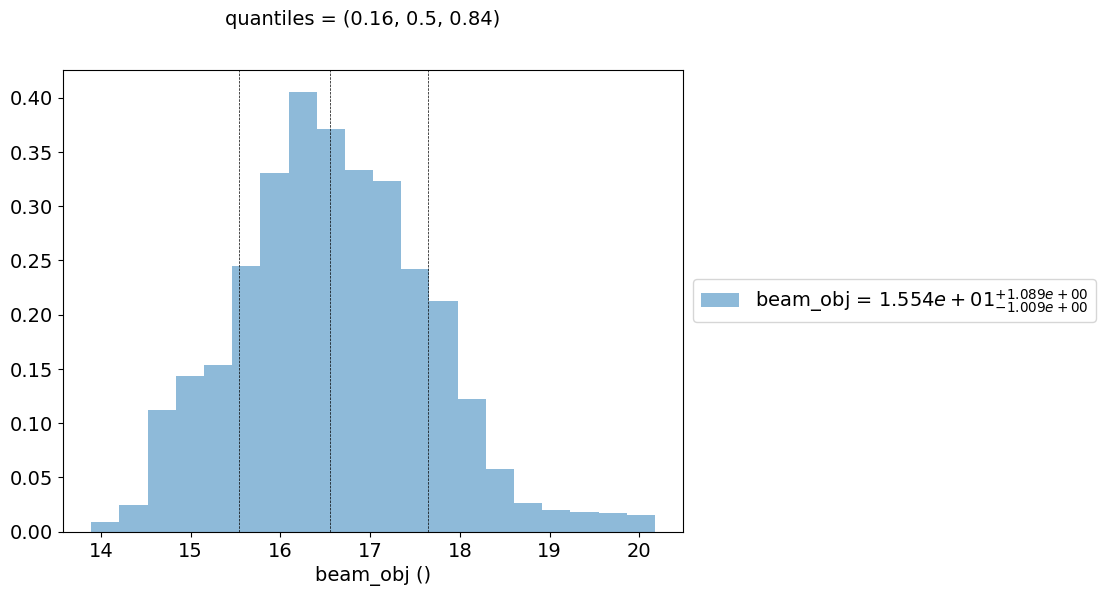

In [52]:
mpl.rcParams['figure.dpi'] = 80
f=ms.plot_par('beam_obj',log_plot=False,figsize=(8,6))

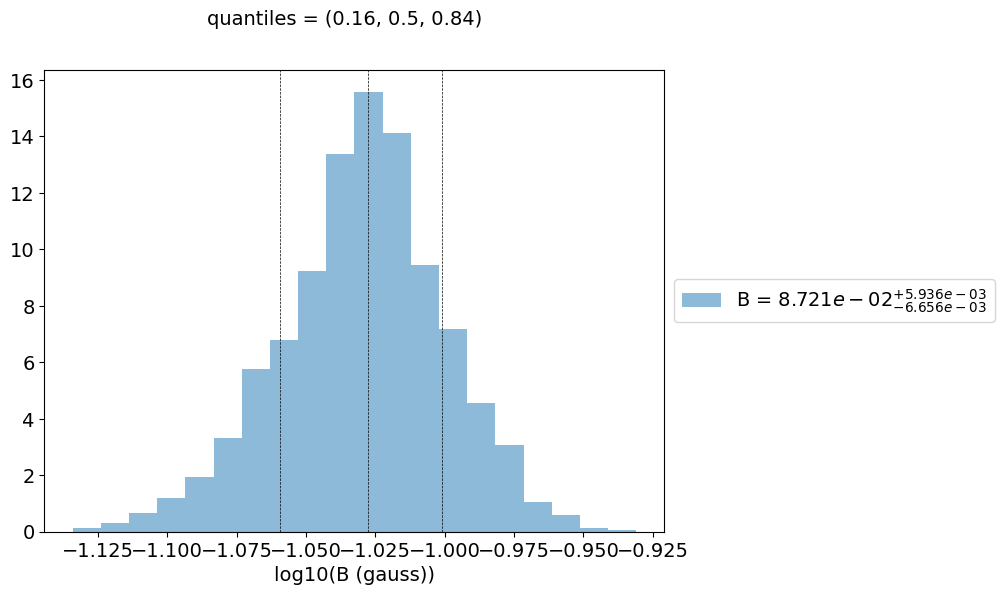

In [53]:
f=ms.plot_par('B',log_plot=True,figsize=(8,6))

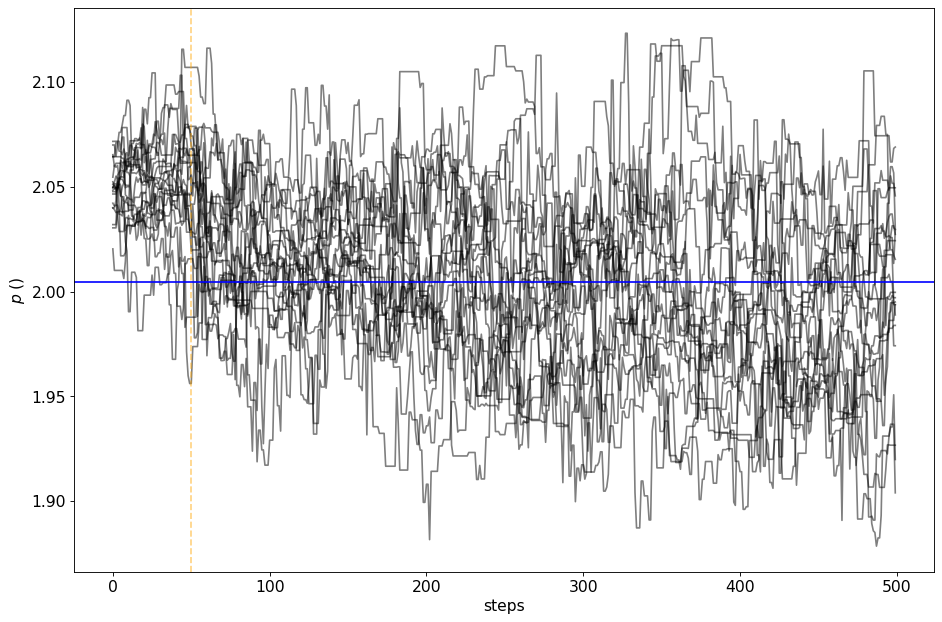

In [54]:
mpl.rcParams['figure.dpi'] = 80
f=ms.plot_chain(par_name='p',log_plot=False)
plt.tight_layout()  

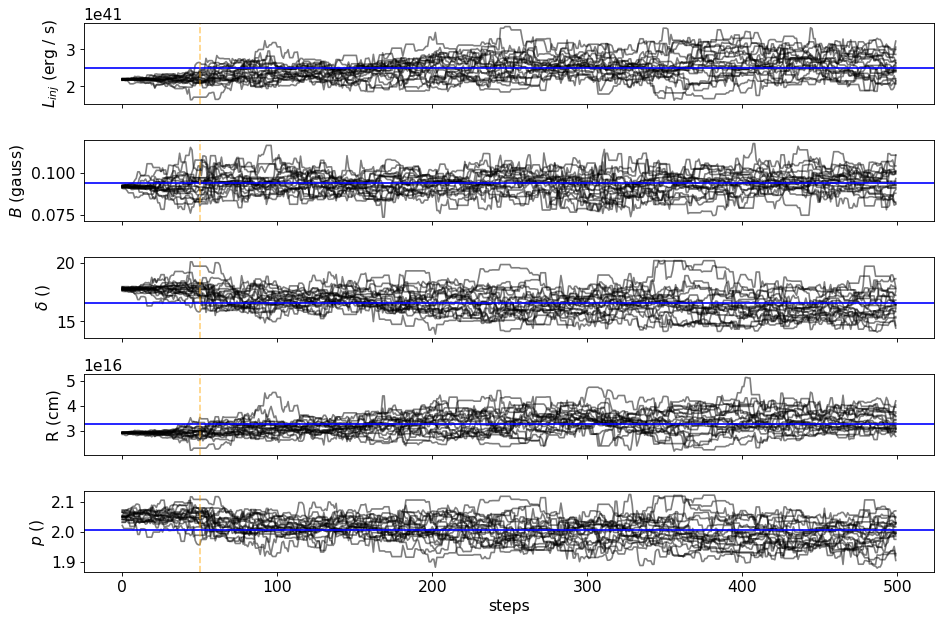

In [55]:
f=ms.plot_chain(log_plot=False)
plt.tight_layout()
mpl.rcParams['figure.dpi'] = 80